## 0. Purpose

This script converts the training data to dataframes. All the classes are undersampled to the number of pixels of the smallest class. The smallest class is the "deadwood". Depending on the RUNMODE (chapter 2) the random forest is trained on just the bands (RUNMODE = BANDS); or the bands + indices + textures (RUNMODE = BANDS). Afterwards a random forest classifier is trained. Feature importance and Accuracy is displayed at the end of the script.

## 1. Import Packages


In [145]:
#%pip install xarray rioxarray pandas matplotlib rasterio
import geopandas as gpd
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import rioxarray
from rasterio import rio
from rasterio import features
from rasterio.enums import Resampling
import numpy as np
from rasterio.transform import Affine
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

## 2. Convert Trainingdata to dataframe

This code block builds the training dataframe.

IF RUNMODE = BANDS; only the original bands of the sent-2 data get used,
IF RUNMODE = INDEX; the orgininal bands and the indices including textures get used

### 2.1 Settings

These settings allow to quickly switche the variables and regions used train and validate the random forest. For example its now possible to train a Random forest based on all sentinel-2 scene and only use it for the scene N22 (north of bavaria, 2022). Its also possible to train a model based on S20 (south of bavaria, 2020) and use it on all the data. REGION_TRAIN_MODE is used for training, REGION_VAL_MODE for validation. If REGION_VAL_MODE and REGION_TRAIN_MODE is the same, a train/validation split of 70/30 is used. The random forest always uses a balanced (undersampled) training data set.

In [146]:
chosen_bands = [ "blue", "green", "red", "rededge1", "rededge2", "rededge3", "nir", "nir_narrow", "swir1", "swir2", "ndvi", "savi", "ndwi", "bsi", "nssi", "contrast"] #options: "blue", "green", "red", "rededge1", "rededge2", "rededge3", "nir", "nir_narrow", "swir1", "swir2", "ndvi", "savi", "ndwi", "bsi", "nssi", "contrast", "dissimilarity", "homogeneity", "energy", "correlation", "ASM"
REGION_TRAIN_MODE = "ALL" # options: "ALL", "N22", "N23", "S20", "S22"
REGION_VAL_MODE = "N22" # options: "ALL", "N22", "N23", "S20", "S22"



### 2.2 Importing Data

This code block opens the required data, removes NAs and converts it to a pd_datframe.

In [147]:
def open_with_labels(path): # small helper function, so the band labels dont get deleted during rioxarray.open_rasterio()
    da = rioxarray.open_rasterio(path)
    if 'long_name' in da.attrs:
        da = da.assign_coords(band=list(da.attrs['long_name']))
    return da


if REGION_TRAIN_MODE == "N22":
        raster = open_with_labels(r"C:\Users\miles\OneDrive\Dokumente\ROOT\trainingdata_collection\trainingdata_withindices\n22.tif")
        raster = raster.drop_sel(band = "std") # not useful and NA most of the time
        df = raster.stack(samples=("y", "x")).to_pandas().T.dropna().reset_index()


if REGION_TRAIN_MODE == "N23":
        raster = open_with_labels(r"C:\Users\miles\OneDrive\Dokumente\ROOT\trainingdata_collection\trainingdata_withindices\n23.tif")
        raster = raster.drop_sel(band = "std")
        df = raster.stack(samples=("y", "x")).to_pandas().T.dropna().reset_index()

if REGION_TRAIN_MODE == "S20":
        raster = open_with_labels(r"C:\Users\miles\OneDrive\Dokumente\ROOT\trainingdata_collection\trainingdata_withindices\s20.tif")
        raster = raster.drop_sel(band = "std") # not useful and NA most of the time
        df = raster.stack(samples=("y", "x")).to_pandas().T.dropna().reset_index()


if REGION_TRAIN_MODE == "S22":
        raster = open_with_labels(r"C:\Users\miles\OneDrive\Dokumente\ROOT\trainingdata_collection\trainingdata_withindices\s22.tif")
        raster = raster.drop_sel(band = "std") # not useful and NA most of the time
        df = raster.stack(samples=("y", "x")).to_pandas().T.dropna().reset_index()

if REGION_TRAIN_MODE == "ALL":
        raster1 = open_with_labels(r"C:\Users\miles\OneDrive\Dokumente\ROOT\trainingdata_collection\trainingdata_withindices\n22.tif")
        raster1 = raster1.drop_sel(band = "std") # not useful and NA most of the time
        raster2 = open_with_labels(r"C:\Users\miles\OneDrive\Dokumente\ROOT\trainingdata_collection\trainingdata_withindices\n23.tif")
        raster2 = raster2.drop_sel(band = "std") # not useful and NA most of the time
        raster3 = open_with_labels(r"C:\Users\miles\OneDrive\Dokumente\ROOT\trainingdata_collection\trainingdata_withindices\s20.tif")
        raster3 = raster3.drop_sel(band = "std") # not useful and NA most of the time
        raster4 = open_with_labels(r"C:\Users\miles\OneDrive\Dokumente\ROOT\trainingdata_collection\trainingdata_withindices\s22.tif")
        raster4 = raster4.drop_sel(band = "std") # not useful and NA most of the time

        r1_flat = raster1.stack(samples=("y", "x")).dropna("samples")
        r2_flat = raster2.stack(samples=("y", "x")).dropna("samples")
        r3_flat = raster3.stack(samples=("y", "x")).dropna("samples")
        r4_flat = raster4.stack(samples=("y", "x")).dropna("samples")

        raster = xr.concat([r1_flat, r2_flat, r3_flat, r4_flat], dim='samples')
        df = raster.to_pandas().T.dropna()
        df = df.reset_index()

df.columns.name = None
df = df.loc[:, ~df.columns.duplicated()]

# 2. Fix the trainclass values (turn 0.0003 into 3)
df["trainclass"] = (df["trainclass"] * 10000).round().astype(int)

# 3. Final selection (Ensures x and y are included without crashing)
final_selection = ["x", "y"] + [b for b in chosen_bands if b not in ["x", "y", "trainclass"]] + ["trainclass"]
df = df[final_selection]

### 2.3 Creating balanced training data

Die Kategorie 2 ("deadwood") ist vermutlich immer das nadelöhr.
The category 2 is the smallest, because areas covered in deadwood are relatively small.

In [148]:
min_size = df["trainclass"].value_counts().min()
print(f"Smallest class size is: {min_size}")

balanced_list = []
for class_id in df["trainclass"].unique():
    class_subset = df[df["trainclass"] == class_id]
    sampled_subset = class_subset.sample(n=min_size, random_state=42)
    balanced_list.append(sampled_subset)
df = pd.concat(balanced_list).reset_index(drop=True)
print("Columns in df_balanced:", df.columns.tolist())
print("Value counts:\n", df["trainclass"].value_counts())

Smallest class size is: 2861
Columns in df_balanced: ['x', 'y', 'blue', 'green', 'red', 'rededge1', 'rededge2', 'rededge3', 'nir', 'nir_narrow', 'swir1', 'swir2', 'ndvi', 'savi', 'ndwi', 'bsi', 'nssi', 'contrast', 'trainclass']
Value counts:
 trainclass
3    2861
1    2861
2    2861
Name: count, dtype: int64


## 3. Random Forest


### 3.1 Creating training and validation data

In [149]:
if REGION_TRAIN_MODE == REGION_VAL_MODE:

    preds = df.drop(columns=["trainclass", "x", "y"])
    forestclass = df["trainclass"]
    pred_train, pred_test, forestclass_train, forestclass_test = train_test_split(preds, forestclass, test_size=0.3, random_state=42)

if REGION_TRAIN_MODE != REGION_VAL_MODE:

    forestclass_train = df["trainclass"]
    pred_train = df.drop(columns=["trainclass", "x", "y"])

    if REGION_VAL_MODE == "N22":
        raster = open_with_labels(r"C:\Users\miles\OneDrive\Dokumente\ROOT\trainingdata_collection\trainingdata_withindices\n22.tif")

    elif REGION_VAL_MODE == "N23":
        raster = open_with_labels(r"C:\Users\miles\OneDrive\Dokumente\ROOT\trainingdata_collection\trainingdata_withindices\n23.tif")

    elif REGION_VAL_MODE == "S20":
        raster = open_with_labels(r"C:\Users\miles\OneDrive\Dokumente\ROOT\trainingdata_collection\trainingdata_withindices\s20.tif")

    elif REGION_VAL_MODE == "S22":
        raster = open_with_labels(r"C:\Users\miles\OneDrive\Dokumente\ROOT\trainingdata_collection\trainingdata_withindices\s22.tif")

    else:
        print("PLEASE USE A VALID REGION_TRAIN_MODE")
        print("not:")
        print(REGION_VAL_MODE)

    raster = raster.drop_sel(band = "std") # not useful and NA most of the time
    df_val = raster.stack(samples=("y", "x")).to_pandas().T.dropna().reset_index()
    df_val.columns.name = None
    df_val = df_val.loc[:, ~df_val.columns.duplicated()]
    df_val["trainclass"] = (df_val["trainclass"] * 10000).round().astype(int)
    final_selection = ["x", "y"] + [b for b in chosen_bands if b not in ["x", "y", "trainclass"]] + ["trainclass"]
    df_val = df_val[final_selection]

    forestclass_test = df_val["trainclass"]
    pred_test = df_val.drop(columns=["trainclass", "x", "y"])


### 3.2 Training

In [150]:
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(pred_train, forestclass_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### 3.3 Predicting


In [151]:
predictions = rf.predict(pred_test)

### 3.4 Accuracy Assessment


1 = clear,
2 = deadwood,
3 = undisturbed


precision = user accuracy

recall = producer accuracy

In [152]:
print(classification_report(forestclass_test, predictions))


              precision    recall  f1-score   support

           1       0.50      0.92      0.65     25745
           2       0.09      1.00      0.16      1513
           3       1.00      0.89      0.94    342186

    accuracy                           0.89    369444
   macro avg       0.53      0.94      0.59    369444
weighted avg       0.96      0.89      0.92    369444



#### 3.4.2 Confusion matrix

In [153]:

confusion_matrix = pd.crosstab(forestclass_test, predictions,
                 rownames=['Actual'],
                 colnames=['Predicted'],
                 margins=True)

print(confusion_matrix)

Predicted      1      2       3     All
Actual                                 
1          23739   1818     188   25745
2              0   1513       0    1513
3          23605  13522  305059  342186
All        47344  16853  305247  369444


### 3.4.3 Overall summary

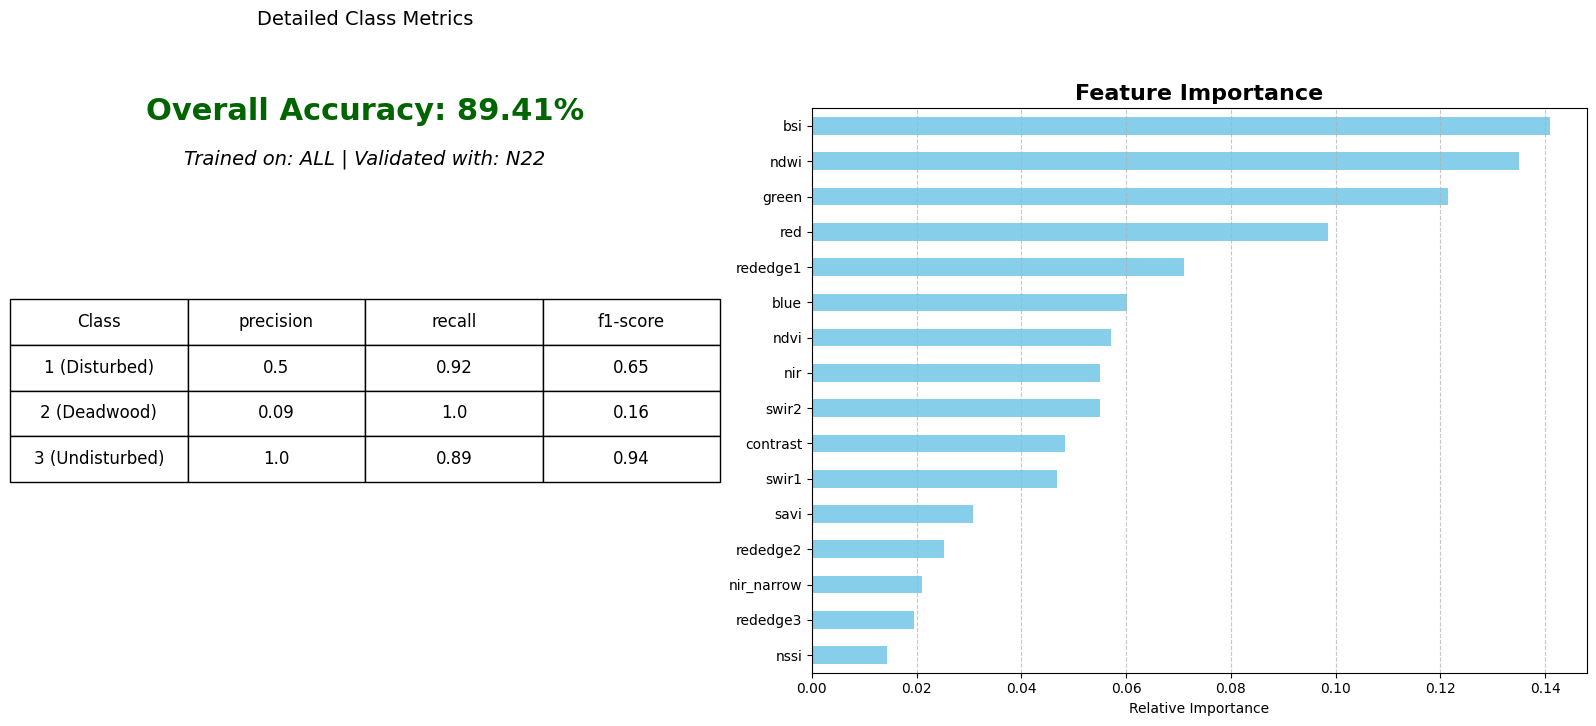

In [154]:
overall_acc = accuracy_score(forestclass_test, predictions)
report_dict = classification_report(forestclass_test, predictions, output_dict=True)

# Create the metrics table
report_df = pd.DataFrame(report_dict).iloc[:-1, :3].T
report_df.index = ['1 (Disturbed)', '2 (Deadwood)', '3 (Undisturbed)']
report_df = report_df.round(2).reset_index().rename(columns={'index': 'Class'})

# Prepare Feature Importance (using pred_train to ensure correct labels)
importances = pd.Series(rf.feature_importances_, index=pred_train.columns).sort_values(ascending=True)

# 2. Dynamic Info Line Logic
if REGION_TRAIN_MODE == REGION_VAL_MODE:
    data_info = f"Trained & Validated on: {REGION_TRAIN_MODE} (70/30 Split)"
else:
    data_info = f"Trained on: {REGION_TRAIN_MODE} | Validated with: {REGION_VAL_MODE}"

# 3. Create Combined Figure
fig, (ax_table, ax_plot) = plt.subplots(1, 2, figsize=(16, 8), gridspec_kw={'width_ratios': [1, 1.2]})

# --- Left Side: Table & Accuracy Score ---
ax_table.axis('off')

# Big Overall Accuracy Score
ax_table.text(0.5, 0.98, f"Overall Accuracy: {overall_acc:.2%}",
              fontsize=22, fontweight='bold', ha='center', color='darkgreen')

# Dynamic Data Source Line
ax_table.text(0.5, 0.90, data_info,
              fontsize=14, fontstyle='italic', ha='center', color='black')

ax_table.set_title('Detailed Class Metrics', fontsize=14, pad=60)
the_table = ax_table.table(cellText=report_df.values,
                           colLabels=report_df.columns,
                           loc='center',
                           cellLoc='center')
the_table.auto_set_font_size(False)
the_table.set_fontsize(12)
the_table.scale(1.1, 3)

# --- Right Side: Bar Plot ---
importances.plot(kind='barh', color='skyblue', ax=ax_plot)
ax_plot.set_title('Feature Importance', fontsize=16, fontweight='bold')
ax_plot.set_xlabel('Relative Importance')
ax_plot.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()